# Looking at gene expression profiles

## Can genes be grouped into clusters based on their expression profiles across cell types?

### loading the RNAseq data with gene names as index

First I have to import all required packages.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Having the gene name as the index and not as an additional column makes the data frame easier to work with.

In [ ]:
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

RNA_seq = pd.read_csv('data/mmc2.csv')

RNA_seq_gd = RNA_seq[Tgd_cells[1:]].copy()

RNA_seq_val = RNA_seq.drop(columns="Unnamed: 0").copy()
RNA_seq_val.index = RNA_seq["Unnamed: 0"]
RNA_seq_val

### K-means based on expression across cell types

I want to try if the genes can be clustered into meaningful groups using k-means.<br>
To reduce the dimensions I will first apply PCA.<br>
As already done in the notebook about clustering cell types this code frist calculates the best number of clusters and then applies k means.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

gene_expr = RNA_seq_val.copy().astype(float)
X_scaled = StandardScaler().fit_transform(gene_expr)

n_components = min(10, X_scaled.shape[1], X_scaled.shape[0] - 1)
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for gene clustering on RNA_seq_gd expression profiles")
plt.grid(True, alpha=0.3)
plt.show()

kmeans_opt = KMeans(n_clusters=6, random_state=42, n_init=20)
labels = kmeans_opt.fit_predict(X_pca)

gene_clusters = pd.DataFrame(
    {
        "gene": gene_expr.index,
        "kmeans_cluster": labels.astype(str),
    }
)

pca_df = pd.DataFrame(X_pca[:, :2], index=gene_expr.index, columns=["PC1", "PC2"])
pca_df["kmeans_cluster"] = gene_clusters["kmeans_cluster"].values

plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab10",
    s=60,
    alpha=0.8,
)
ax.set_xscale("log")
ax.set_yscale("linear")
plt.title(f"KMeans gene clustering on RNA_seq_gd profiles (k={6})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="cluster", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

print(gene_clusters.groupby("kmeans_cluster").size().sort_values(ascending=False))


I am using 6 cluster instead of the number with the highest silhouette score, because then it would be just 2 groups.<br>
The log scale of PC1 helps to see the determined groups.

- no destinct groups can be seen
- other clustering methods could be better

#### trying out clustering of log transformed expression values

Log transformation could help to make differences between genes more accessible for k-means clustering.<br>
First I will create a log-transform function as before in the notebook about RNAseq filtering.

In [ ]:
def log_transform(df):
    df_numeric_cols = df.select_dtypes(include=[np.number]).columns
    log_df = df.copy()
    log_df[df_numeric_cols] = np.log1p(log_df[df_numeric_cols])
    return log_df

The code applying PCA and k-means is the same as before.

In [ ]:
gene_expr_log = log_transform(RNA_seq_val).copy().astype(float)
X_scaled_log = StandardScaler().fit_transform(gene_expr_log)

n_components = min(10, X_scaled_log.shape[1], X_scaled_log.shape[0] - 1)
pca_log = PCA(n_components=n_components, random_state=42)
X_pca_log = pca_log.fit_transform(X_scaled_log)

silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca_log)
    score = silhouette_score(X_pca_log, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for gene clustering on RNA_seq_gd expression profiles")
plt.grid(True, alpha=0.3)
plt.show()

kmeans_opt_log = KMeans(n_clusters=7, random_state=42, n_init=20)
labels = kmeans_opt_log.fit_predict(X_pca_log)

gene_clusters_log = pd.DataFrame(
    {
        "gene": gene_expr.index,
        "kmeans_cluster": labels.astype(str),
    }
)

pca_df_log = pd.DataFrame(X_pca_log[:, :2], index=gene_expr.index, columns=["PC1", "PC2"])
pca_df_log["kmeans_cluster"] = gene_clusters_log["kmeans_cluster"].values

plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    data=pca_df_log,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab10",
    s=60,
    alpha=0.8,
)
ax.set_xscale("linear")
ax.set_yscale("linear")
plt.title(f"KMeans gene clustering on RNA_seq_gd profiles (with log transformation) (k={7})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="cluster", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

print(gene_clusters_log.groupby("kmeans_cluster").size().sort_values(ascending=False))


I have choosen 7 groups rather than 2 (has the highest silhouette score), because 7 cluster has the highest score after the continuous drop from 2 to 6.

- there are still no clear groups visible 
- the results are similar as without the log tranform

#### coloring the genes in the PCA plot by their biological function (look at the scatter plot from RNA-seq_data_filtering_and_visualization.ipynb)

This code is copied from the previous notebook

In [ ]:
import gseapy as gp

go_genesets = gp.get_library(name='GO_Biological_Process_2023', organism='Mouse')

gene2terms = {}
for term, genes in go_genesets.items():
    for gene in genes:
        gene2terms.setdefault(gene, set()).add(term)

category_keywords = {
    "housekeeping":  ["ribosom", "translation", "RNA processing",
                      "proteasome", "DNA repair", "cell cycle"],
    "immune":        ["immune", "T cell", "lymphocyte", "cytokine",
                      "interferon", "NF-kB", "antigen"],
    "metabolism":    ["metabolic", "biosynthesis", "oxidation",
                      "glycolysis", "lipid", "mitochondri"],
    "transcription": ["transcription", "chromatin", "histone", "epigenetic"],
    "signaling":     ["signaling", "kinase", "receptor", "MAPK", "PI3K"],
}

In [ ]:
def assign_category(gene):
    terms = gene2terms.get(gene.upper(), set())   
    for category, keywords in category_keywords.items():
        for t in terms:                   
            for kw in keywords:           
                if kw.lower() in t.lower():
                    return category       
    return "other"     

In [ ]:
color_map = {
    "housekeeping":  "#2196F370",  
    "immune":        "#F4433670",  
    "metabolism":    "#4CAF5070",  
    "transcription": "#FF980070",  
    "signaling":     "#9C27B070",  
    "other":         "#CCCCCC30",  
}

color_map_housekeeping = {  
    "housekeeping":  "#2196F3",  
    "immune":        "#F4433600",  
    "metabolism":    "#4CAF4F00",  
    "transcription": "#FF990000",  
    "signaling":     "#9B27B000",
    "other":         "#CCCCCC30",  
}

color_map_immune = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#F44336",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC30",  
}

color_map_metabolism = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#4CAF50",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC30",  
}

color_map_transcription = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#FF9800",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC30",  
}

color_map_signaling = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#9C27B0",  
    "other":         "#CCCCCC30",  
}

I am applying the colormaps to both plots from before (with and without log transformation).

In [ ]:
pca_df = pd.DataFrame(X_pca[:, :2], index=gene_expr.index, columns=["PC1", "PC2"])
pca_df["gene_category"] = pca_df.index.map(assign_category)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="gene_category",
    palette=color_map_housekeeping,
    s=60,
)
plt.xscale("log")
plt.yscale("linear")
plt.title("PCA of gene expression on RNA_seq_gd profiles")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="category", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()




pca_df_log = pd.DataFrame(X_pca_log[:, :2], index=gene_expr.index, columns=["PC1", "PC2"])
pca_df_log["gene_category"] = pca_df_log.index.map(assign_category)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df_log,
    x="PC1",
    y="PC2",
    hue="gene_category",
    palette=color_map_housekeeping,
    s=60,
)
plt.xscale("linear")
plt.yscale("linear")
plt.title("PCA of gene expression on RNA_seq_gd profiles (with log transformation)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="category", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()


- genes do not seem to group by their biological function in these PCA plots

### using Gini index to identify cell type specific genes

The Gini score quantifies how specific a gene is expressed.<br>
Gene with a high score are only expressed in a few cell types, whereas a score of 0 would mean, that the gene is expressed at the same level in every cell type.

computing the Gini score for each gene (function was created using Claude Sonnet 4.6)<br>
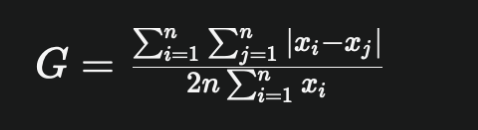

In [ ]:
# --- Gini index function ---
def gini(x):
    """
    Compute the Gini coefficient for a 1D array of expression values.
    Returns a value between 0 (uniform) and 1 (fully specific).
    """
    x = np.array(x, dtype=float)
    x = x[x >= 0]           # remove negative values if any
    if x.sum() == 0:
        return 0.0           # no expression → not informative
    x = np.sort(x)           # sort ascending
    n = len(x)
    cumulative = np.cumsum(x)
    # Gini formula based on the area under the Lorenz curve
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * x.sum()) / (n * x.sum())

RNA_seq_gini = RNA_seq_val.copy()
RNA_seq_gini["gini_score"] = RNA_seq_gini.apply(gini, axis=1)

visualizing the Gini Score using a Umap of all genesy<br>
The genes are colored acording to their gini score.

In [ ]:
import umap
import matplotlib.cm as cm
import matplotlib.colors as mcolors


reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=30,    
    min_dist=0.1       
)
embedding = reducer.fit_transform(RNA_seq_val.values)

gini_scores = RNA_seq_gini["gini_score"].values
norm = mcolors.Normalize(vmin=gini_scores.min(), vmax=gini_scores.max())
cmap = sns.color_palette("ch:s=-.2,r=.6", as_cmap=True) 

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    embedding[:, 0], embedding[:, 1],
    c=gini_scores,          
    cmap=cmap,
    norm=norm,
    s=3,                    
    alpha=0.7,
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Gini Score", fontsize=12)
cbar.ax.tick_params(labelsize=10)
ax.set_title("UMAP of Genes — colored by Gini Score")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.savefig('tilmann_plots/Umap of Genes - colored by Gini Score', dpi=300)
plt.show()

- genes with high gini score tend to cluster together
- connecting gini score to gene function is difficult (see next part)
    - could be the case be there are just immune cells available

### coloring the Umap with the categorizes, which were used in the gene variance scatter plot

this code is copied from the notebook RNA-seq_data_filtering_and_visualization.ipynb

In [ ]:
import gseapy as gp

go_genesets = gp.get_library(name='GO_Biological_Process_2023', organism='Mouse')

gene2terms = {}
for term, genes in go_genesets.items():
    for gene in genes:
        gene2terms.setdefault(gene, set()).add(term)

category_keywords = {
    "housekeeping":  ["ribosom", "translation", "RNA processing",
                      "proteasome", "DNA repair", "cell cycle"],
    "immune":        ["immune", "T cell", "lymphocyte", "cytokine",
                      "interferon", "NF-kB", "antigen"],
    "metabolism":    ["metabolic", "biosynthesis", "oxidation",
                      "glycolysis", "lipid", "mitochondri"],
    "transcription": ["transcription", "chromatin", "histone", "epigenetic"],
    "signaling":     ["signaling", "kinase", "receptor", "MAPK", "PI3K"],
}

def assign_category(gene):
    terms = gene2terms.get(gene.upper(), set())   
    for category, keywords in category_keywords.items():
        for t in terms:                   
            for kw in keywords:           
                if kw.lower() in t.lower():
                    return category       
    return "other"   

In [ ]:
RNA_seq_annot = RNA_seq.copy()

RNA_seq_annot["category"] = RNA_seq["Unnamed: 0"].apply(assign_category)
RNA_seq_annot.head()

defining the colormaps as before in the metioned notebook

In [ ]:
color_map = {
    "housekeeping":  "#2196F370",  
    "immune":        "#F4433670",  
    "metabolism":    "#4CAF5070",  
    "transcription": "#FF980070",  
    "signaling":     "#9C27B070",  
    "other":         "#CCCCCC70",  
}

color_map_housekeeping = {  
    "housekeeping":  "#2196F3",  
    "immune":        "#F4433600",  
    "metabolism":    "#4CAF4F00",  
    "transcription": "#FF990000",  
    "signaling":     "#9B27B000",
    "other":         "#CCCCCC70",  
}

color_map_immune = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#F44336",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC70",  
}

color_map_metabolism = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#4CAF50",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC70",  
}

color_map_transcription = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#FF9800",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC70",  
}

color_map_signaling = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#9C27B0",  
    "other":         "#CCCCCC70",  
}

In [ ]:
import umap

reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=30,    
    min_dist=0.1       
)
embedding = reducer.fit_transform(RNA_seq_val.values)


fig, ax = plt.subplots(figsize=(10, 8))

for category in ["other"] + [k for k in color_map if k != "other"]:
    mask = RNA_seq_annot["category"] == category
    if not mask.any():
        continue

    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        c=color_map_housekeeping[category],
        label=f"{category} (n={mask.sum()})",
        s=5
    )


ax.set_title("UMAP of Genes — colored by gene function")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(markerscale=4, loc="upper right")
plt.savefig("tilmann_plots/UMAP of Genes - colored by gene function")
plt.show()

- the genes do not group together acording to their function in this Umap plot

### clustering genes using hirachrical clustering (only genes with highest Gini score)

I am only using the genes with the highest Gini score (above 0.8), because these are of special interest when finding cell type specific markers.

In [ ]:
high_gini_genes = RNA_seq_gini[RNA_seq_gini["gini_score"] >= 0.80].copy()

removing the gini score from the data frame 

In [ ]:
high_gini_genes_val = high_gini_genes[high_gini_genes.columns[0:86]].copy()
high_gini_genes_val

to make genes more comparable I apply a z transfromation (setting the mean to 0 and std to 1)

In [ ]:
high_gini_genes_val_z = high_gini_genes_val.sub(high_gini_genes_val.mean(axis=1), axis=0).div(high_gini_genes_val.std(axis=1), axis=0)
high_gini_genes_val_z = high_gini_genes_val_z.dropna(axis=0)
high_gini_genes_val_z.describe()

The following plot is a heatmap of z transformed expression values and hierarchcal clustering of the genes. This should give better clustering than with k-means.

In [ ]:
import seaborn as sns


vmin, vmax = high_gini_genes_val_z.min().min(), high_gini_genes_val_z.max().max()

g = sns.clustermap(
    high_gini_genes_val_z,                 
    row_cluster=True,
    col_cluster=False,
    method='average',
    metric='euclidean',
    cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True),
    center=((vmin + vmax) / 2),
    vmin=vmin,
    vmax=vmax,           
    figsize=(30, 30),
    dendrogram_ratio=(0.15, 0.02),
    cbar_pos=None,
    yticklabels=False,
)

g.ax_heatmap.tick_params(axis='x', labelsize=10)
g.figure.subplots_adjust(right=0.88)
cax = g.figure.add_axes([0.92, 0.2, 0.02, 0.3])
plt.colorbar(g.ax_heatmap.collections[0], cax=cax)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
g.ax_heatmap.set_xlabel("Cell types", fontsize=20)
g.ax_heatmap.set_ylabel("Genes", fontsize=20)
plt.savefig('tilmann_plots/hierarchical clustering of genes based on expression profile (highest gini genes).png', dpi=300, bbox_inches='tight')
plt.savefig('plots_for_poster/hierarchical clustering of genes based on expression profile (highest gini genes).png', dpi=300, bbox_inches='tight')
plt.show()


 - many genes are mostly expressed in myeloid cell types
 - B-cells, stem-cells, and NK-cells have distinct sets of genes which are expressed throughout the groups
 - Treg-cells have a very specicfic set of genes not being expressed anywhere else
 - some genes seem to be destinct for a few Tgd-cells, but as clearly as for other cell types
 - it is not realy possible to identify shared genes between IL17 expressing cells

#### doing the same, but just with our cells

The cells choosen here are all from the Tgd lineage

In [ ]:
Tgd_cells = ["MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

apart from the reduced number of cell types the code is the same

In [ ]:
Tgd_high_gini = high_gini_genes_val[Tgd_cells].copy()

Tgd_high_gini_z = Tgd_high_gini.sub(Tgd_high_gini.mean(axis=1), axis=0).div(Tgd_high_gini.std(axis=1), axis=0)
Tgd_high_gini_z = Tgd_high_gini_z.dropna(axis=0)


vmin, vmax = Tgd_high_gini_z.min().min(), Tgd_high_gini_z.max().max()

g = sns.clustermap(
    Tgd_high_gini_z,                 
    row_cluster=True,
    col_cluster=False,
    method='average',
    metric='euclidean',
    cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True),
    center=((vmin + vmax) / 2),
    vmin=vmin,
    vmax=vmax,           
    figsize=(10, 10),
    dendrogram_ratio=(0.15, 0.02),
    cbar_pos=None,
    yticklabels=False,
)

g.figure.subplots_adjust(right=0.88)
cax = g.figure.add_axes([0.92, 0.2, 0.02, 0.3])
plt.colorbar(g.ax_heatmap.collections[0], cax=cax)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
g.ax_heatmap.set_xlabel("Cell types")
g.ax_heatmap.set_ylabel("Genes")
plt.savefig('tilmann_plots/hierarchical clustering of genes based on expression profile (highest gini genes and only Tgd cells).png', dpi=300, bbox_inches='tight')
plt.savefig('plots_for_poster/hierarchical clustering of genes based on expression profile (highest gini genes and only Tgd cells).png', dpi=300, bbox_inches='tight')
plt.show()

- the stem cells have a large distinst group of genes
- the is also a distinct cluster for the IL17 producing Tgd cells 
- in generall the overlap between cell types is not that visible (also due to the usage of high-gini-genes)
    - more overlap between the Tgd cells than with their progenitors
- gene cluster roughly represent cell lineage
    - the unique genes from the fully differentiated Tgd cell types are clustered together
    - genes from early progenitors are clustered together
    - genes from partially differentiated cells are clustered (both Tgd and Tab, even tough they are still quite seperate)

### hierachical clusterin of genes based on expression profiles (all genes)

Since hierarichal clustering of the genes with high gini scores did not take to long I will try to do it for all genes. This could reveal genes being expressed in all cell types like housekeeping genes (these are lost when filtering by gini score).

In [ ]:
RNA_seq_z = RNA_seq_val.sub(RNA_seq_val.mean(axis=1), axis=0).div(RNA_seq_val.std(axis=1), axis=0)
RNA_seq_z = RNA_seq_z.dropna(axis=0)


vmin, vmax = RNA_seq_z.min().min(), RNA_seq_z.max().max()

g = sns.clustermap(
    RNA_seq_z,                 
    row_cluster=True,
    col_cluster=False,
    method='average',
    metric='euclidean',
    cmap="viridis",
    center=((vmin + vmax) / 2),
    vmin=vmin,
    vmax=vmax,           
    figsize=(30, 30),
    dendrogram_ratio=(0.15, 0.02),
    cbar_pos=None,
    yticklabels=False,
)

g.figure.subplots_adjust(right=0.88)
cax = g.figure.add_axes([0.92, 0.2, 0.02, 0.3])
plt.colorbar(g.ax_heatmap.collections[0], cax=cax)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
g.ax_heatmap.set_xlabel("Cell types")
g.ax_heatmap.set_ylabel("Genes")
g.figure.suptitle('hierarchical clustering of all genes based on expression profile', y=1, fontsize = 30)
plt.savefig('tilmann_plots/hierarchical clustering of all genes based on expression profile.png', dpi=300, bbox_inches='tight')
plt.show()

- no clear housekeeping genes or similar groups can be seen
- cell type specific gene cluster are better visible, when only the high-gini-genes are clustered

## Can you identify a lineage-specific gene set for your assigned cell type?

This part should identify the gene sets, which were already visible in the previous heatmaps

### identify specific genes using the Gini Score

creating the list of cell types interesting to us

In [ ]:
Tgd_cells = ["MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

filtering what genes are specifc for some cell types using the gini score<br>

In [ ]:
high_gini_genes = RNA_seq_gini[RNA_seq_gini["gini_score"] >= 0.80].copy()

top_gini_genes = RNA_seq_gini.nlargest(100, "gini_score").copy()

expr_only = high_gini_genes.drop(columns=["gini_score"])

high_gini_genes["dominant_cell_type"] = expr_only.idxmax(axis=1)

high_gini_genes["specificity_ratio"] = expr_only.max(axis=1) / expr_only.mean(axis=1)

marker_table = (
    high_gini_genes[["gini_score", "dominant_cell_type", "specificity_ratio"]]
    .sort_values(["dominant_cell_type", "gini_score"], ascending=[True, False])
)

This gives the cell type with highest expression for each gene

the specificity ratio is just a rough measurement, which is not important for further analysis

I do not only want the dominant cell type, but I want a list of genes for each cell type. This is done in the following code. The threshold choosen is adjusted to get a reasonable number of genes per cell type.

In [ ]:
gene_threshold = expr_only.mean(axis=1) + (1 * expr_only.std(axis=1)) 


marker_dict = {}

for cell_type in expr_only.columns:
    genes_above_threshold = expr_only.index[expr_only[cell_type] > gene_threshold].tolist()
    marker_dict[cell_type] = genes_above_threshold


max_len = max(len(g) for g in marker_dict.values())

specific_genes = pd.DataFrame({
    cell_type: genes + [""] * (max_len - len(genes))
    for cell_type, genes in marker_dict.items()
})

specific_genes

These lists should roughly represent the groups visible in the heatmap from the previous section.<br>
The genes should be usable to identify these cell types when performing RNAseq.

#### what genes are specifically expressed in our cell types?

I am creating a new data frame and not just using the one from above, beacause I want to adjust the threshold idividualy and otherwise cell types not intersting to us whould influence the results.

In [ ]:
Tgd_expr_only = expr_only[Tgd_cells].copy()

In [ ]:
Tgd_gene_threshold = Tgd_expr_only.mean(axis=1) + (1.96 * Tgd_expr_only.std(axis=1)) 


Tgd_marker_dict = {}

for cell_type in Tgd_expr_only.columns:
    Tgd_genes_above_threshold = Tgd_expr_only.index[Tgd_expr_only[cell_type] > Tgd_gene_threshold].tolist()
    Tgd_marker_dict[cell_type] = Tgd_genes_above_threshold


max_len = max(len(g) for g in Tgd_marker_dict.values())

Tgd_specific_genes = pd.DataFrame({
    cell_type: genes + [""] * (max_len - len(genes))
    for cell_type, genes in Tgd_marker_dict.items()
})

Tgd_specific_genes

- These lists of genes should roughly represent the clusters from the heatmap
- number of specific genes tends to decrease as the cells get more differentiated
- IL17 is not listed, because it is expressed in multiple cell types and does not have a high Gini score

#### coloring the Umap scatter plot with the specific genes for Tgd cells

I am using the same Umap plot as before, but color the genes acording to their assigned cell type

In [ ]:
# coloring was done with Claude Sonnet 4.6

reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=30,
    min_dist=0.1
)
embedding = reducer.fit_transform(RNA_seq_val.values)

column_colors = {
    col: color
    for col, color in zip(
        Tgd_specific_genes.columns,
        plt.cm.tab20(np.linspace(0, 1, len(Tgd_specific_genes.columns)))
    )
}

point_colors = []
point_sizes = []
for gene in RNA_seq_gini.index:
    matching_columns = [
        col for col in Tgd_specific_genes.columns
        if str(gene) in Tgd_specific_genes[col].dropna().astype(str).tolist()
    ]
    if matching_columns:
        point_colors.append(column_colors[matching_columns[0]])
        point_sizes.append(20)
    else:
        point_colors.append("#bdbdbd")
        point_sizes.append(6)

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=point_colors,
    s=point_sizes,
    alpha=0.7,
)

legend_handles = [
    plt.Line2D(
        [0], [0], marker='o', color='w', label=col,
        markerfacecolor=column_colors[col], markeredgecolor=column_colors[col], markersize=8
    )
    for col in Tgd_specific_genes.columns
]
legend_handles.append(
    plt.Line2D([0], [0], marker='o', color='w', label='Not listed',
              markerfacecolor='#bdbdbd', markeredgecolor='#bdbdbd', markersize=8)
)
ax.legend(handles=legend_handles, loc='upper right')

ax.set_title("UMAP of Genes — Tgd-specific genes highlighted")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.savefig('tilmann_plots/Umap of Genes - highlighted specific genes for Tgd cells', dpi=300)
plt.show()

- no groups of genes associated with a certain cell type can be seen

### calculating the mean expression of genes across cell groups and then calculating Gini score to identify group-specific genes

I have to remove some of the cell types from the data frame, because they are not listed in the RNAseq data

In [ ]:
cells_groups = pd.read_csv('data/cells_groups.csv')
cells_groups.loc[cells_groups["Act_T"] == "T8.IEL.LCMV.d7.SI", "Act_T"] = np.nan
cells_groups.loc[cells_groups["B_cells"] == "preB.FrD.BM", "B_cells"] = np.nan
cells_groups.loc[cells_groups["MF/GN"] == "MF.LP.SI", "MF/GN"] = np.nan
cells_groups.loc[cells_groups["DC"] == "DC.103+11b+.SI", "DC"] = np.nan
cells_groups.loc[cells_groups["DC"] == "DC.103+11b-.SI"] = np.nan
cells_groups

I am calculating the mean expression for each gene across all cell types in one group

In [ ]:
RNA_seq_group_val = pd.DataFrame({
    "gdT": RNA_seq_val[cells_groups["gdT"].dropna()].mean(axis=1),
    "abT": RNA_seq_val[cells_groups["abT"].dropna()].mean(axis=1),
    "Act_T": RNA_seq_val[cells_groups["Act_T"].dropna()].mean(axis=1),
    "B_cells": RNA_seq_val[cells_groups["B_cells"].dropna()].mean(axis=1),
    "Stem": RNA_seq_val[cells_groups["Stem"].dropna()].mean(axis=1),
    "ILC": RNA_seq_val[cells_groups["ILC"].dropna()].mean(axis=1),
    "MF/GN": RNA_seq_val[cells_groups["MF/GN"].dropna()].mean(axis=1),
    "Mo": RNA_seq_val[cells_groups["Mo"].dropna()].mean(axis=1),
    "DC": RNA_seq_val[cells_groups["DC"].dropna()].mean(axis=1),
    "Stroma": RNA_seq_val[cells_groups["Stroma"].dropna()].mean(axis=1),
})
RNA_seq_group_val

The following code matches what was used in the previous part, but just uses the data frame with the avarage expression across the cell groups.

In [ ]:
RNA_seq_group_gini = RNA_seq_group_val.copy()
RNA_seq_group_gini["gini_score"] = RNA_seq_group_gini.apply(gini, axis=1)

In [ ]:
high_gini_group_genes = RNA_seq_group_gini[RNA_seq_group_gini["gini_score"] >= 0.80].copy()

expr_only_group = high_gini_group_genes.drop(columns=["gini_score"])

high_gini_group_genes["dominant_cell_type"] = expr_only_group.idxmax(axis=1)

high_gini_group_genes["specificity_ratio"] = expr_only_group.max(axis=1) / expr_only_group.mean(axis=1)

The threshold was again choosen to get a reasonable number of genes per cell group.

In [ ]:
gene_threshold_group = expr_only_group.mean(axis=1) 


marker_dict_group = {}

for cell_type in expr_only_group.columns:
    genes_above_threshold_group = expr_only_group.index[expr_only_group[cell_type] > gene_threshold_group].tolist()
    marker_dict_group[cell_type] = genes_above_threshold_group


max_len = max(len(g) for g in marker_dict_group.values())

specific_genes_group = pd.DataFrame({
    cell_type: genes + [""] * (max_len - len(genes))
    for cell_type, genes in marker_dict_group.items()
})

specific_genes_group

#### coloring the Umap scatter plot with the group-specific genes

To visualize the results I am again using the Umap plot and coloring the genes acording to their assigned cell group

In [ ]:
# coloring was done with Claude Sonnet 4.6

reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=30,
    min_dist=0.1
)
embedding = reducer.fit_transform(RNA_seq_val.values)

column_colors = {
    col: color
    for col, color in zip(
        specific_genes_group.columns,
        plt.cm.tab10(np.linspace(0, 1, len(specific_genes_group.columns)))
    )
}

point_colors = []
point_sizes = []
for gene in RNA_seq_group_gini.index:
    matching_columns = [
        col for col in specific_genes_group.columns
        if str(gene) in specific_genes_group[col].dropna().astype(str).tolist()
    ]
    if matching_columns:
        point_colors.append(column_colors[matching_columns[0]])
        point_sizes.append(20)
    else:
        point_colors.append("#bdbdbd")
        point_sizes.append(6)

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=point_colors,
    s=point_sizes,
    alpha=0.7,
)

legend_handles = [
    plt.Line2D(
        [0], [0], marker='o', color='w', label=col,
        markerfacecolor=column_colors[col], markeredgecolor=column_colors[col], markersize=8
    )
    for col in specific_genes_group.columns
]
legend_handles.append(
    plt.Line2D([0], [0], marker='o', color='w', label='Not listed',
              markerfacecolor='#bdbdbd', markeredgecolor='#bdbdbd', markersize=8)
)
ax.legend(handles=legend_handles, loc='upper right')

ax.set_title("UMAP of Genes — group-specific genes highlighted")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.savefig('tilmann_plots/Umap of Genes - highlighted specific genes by column', dpi=300)
plt.savefig('plots_for_poster/Umap of Genes - highlighted specific genes by column', dpi=300)
plt.show()

- some groups are visible, but there is no clear seperation
- it again shows which regions in this scatter plot contain more genes with a high Gini score